# Batched linalg timing: cuSOLVER vs MAGMA

Visualize results from `GPU/scripts/torch_linalg_timing.py`.
Data: `GPU/data/linalg_timing_B=64.npy`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('../data/linalg_timing_B=64.npy', allow_pickle=True).item()
n_arr = np.array(data['n_list'])
B = data['B']
res_default = data['default']
res_magma = data['magma']

print(f"B={B}, n={n_arr[0]}..{n_arr[-1]}, {len(n_arr)} sizes")

B=64, n=4..256, 40 sizes


## Absolute times (log scale)

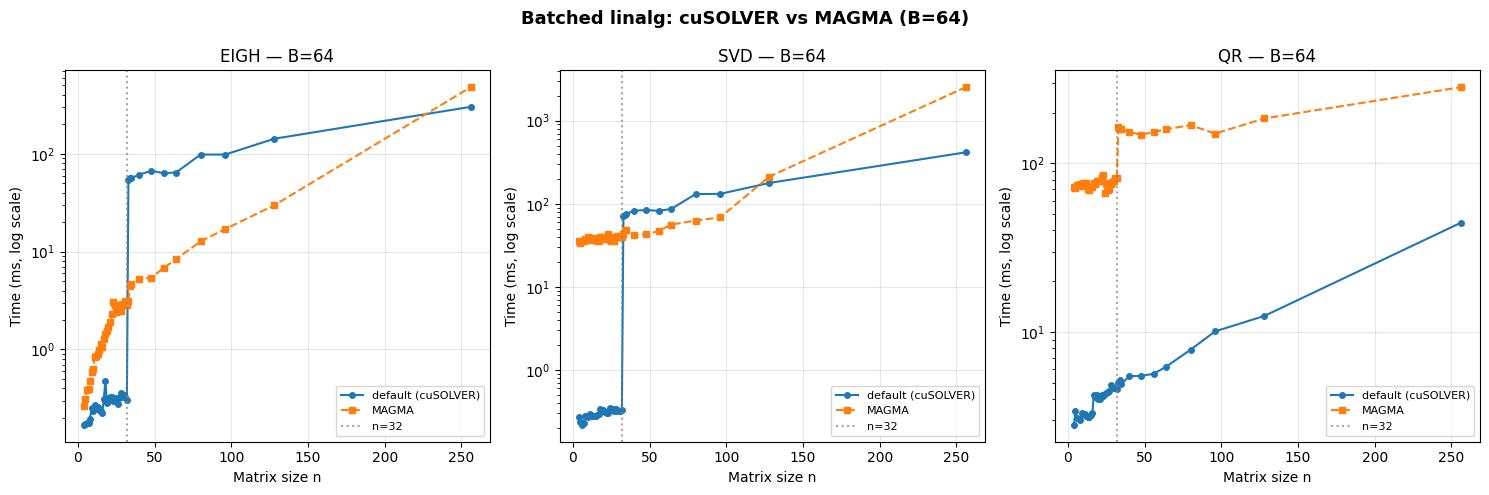

In [2]:
ops = ['eigh', 'svd', 'qr']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, op in zip(axes, ops):
    key = f'{op}_ms'
    ax.semilogy(n_arr, res_default[key], 'o-', ms=4, label='default (cuSOLVER)')
    ax.semilogy(n_arr, res_magma[key], 's--', ms=4, label='MAGMA')
    ax.axvline(x=32, color='gray', ls=':', alpha=0.7, label='n=32')
    ax.set_xlabel('Matrix size n')
    ax.set_ylabel('Time (ms, log scale)')
    ax.set_title(f'{op.upper()} — B={B}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Batched linalg: cuSOLVER vs MAGMA (B={B})', fontsize=13, fontweight='bold')
fig.tight_layout()
# plt.show()
plt.savefig('./cuSOLVER_vs_MAGMA_timing.pdf', dpi=300, bbox_inches='tight')

## Speedup ratio (default / MAGMA)

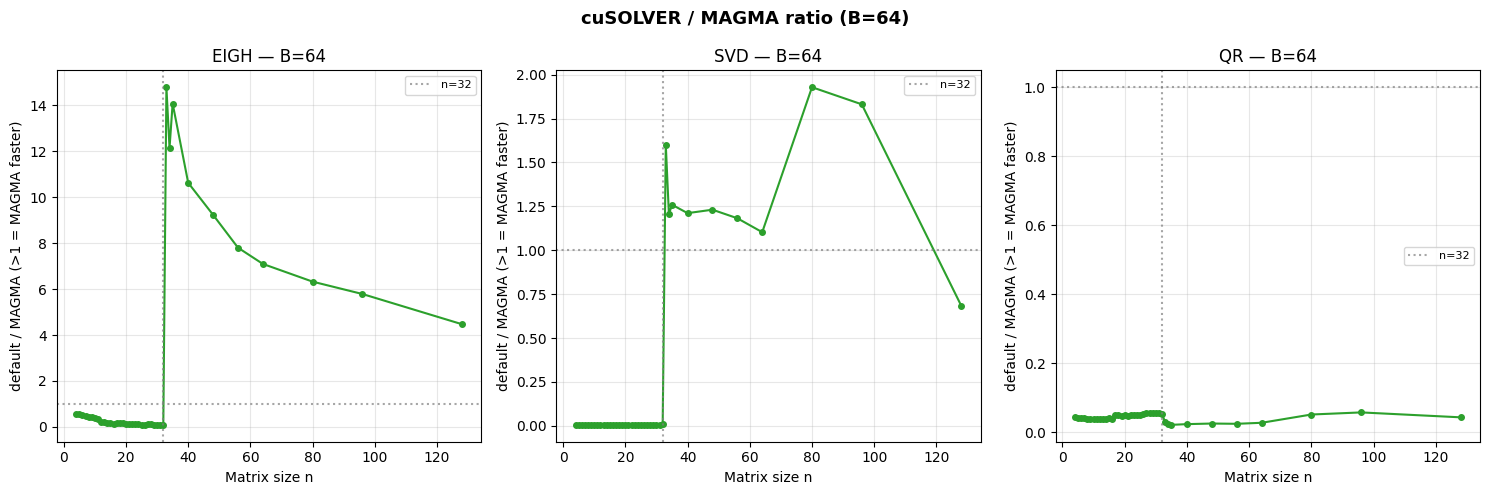

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, op in zip(axes, ops):
    key = f'{op}_ms'
    ratios = np.array(res_default[key]) / np.array(res_magma[key])
    ax.plot(n_arr, ratios, 'o-', ms=4, color='tab:green')
    ax.axhline(y=1.0, color='gray', ls=':', alpha=0.7)
    ax.axvline(x=32, color='gray', ls=':', alpha=0.7, label='n=32')
    ax.set_xlabel('Matrix size n')
    ax.set_ylabel('default / MAGMA (>1 = MAGMA faster)')
    ax.set_title(f'{op.upper()} — B={B}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'cuSOLVER / MAGMA ratio (B={B})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## All ops on one plot (default backend only)

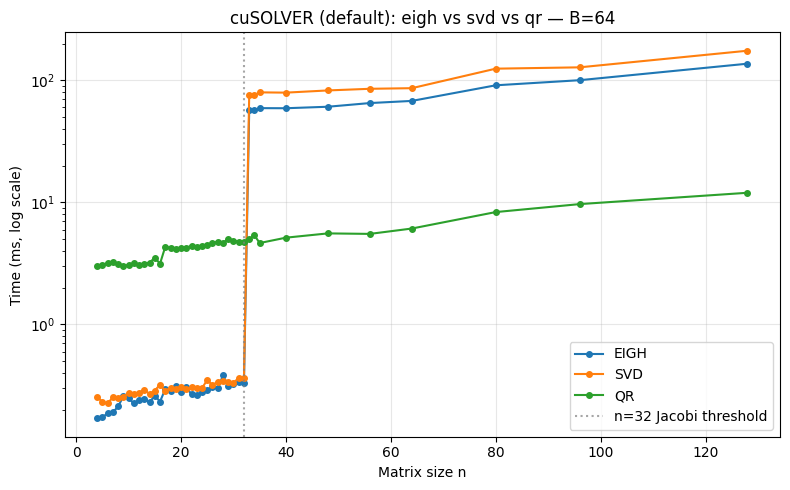

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for op in ops:
    key = f'{op}_ms'
    ax.semilogy(n_arr, res_default[key], 'o-', ms=4, label=op.upper())

ax.axvline(x=32, color='gray', ls=':', alpha=0.7, label='n=32 Jacobi threshold')
ax.set_xlabel('Matrix size n')
ax.set_ylabel('Time (ms, log scale)')
ax.set_title(f'cuSOLVER (default): eigh vs svd vs qr — B={B}')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

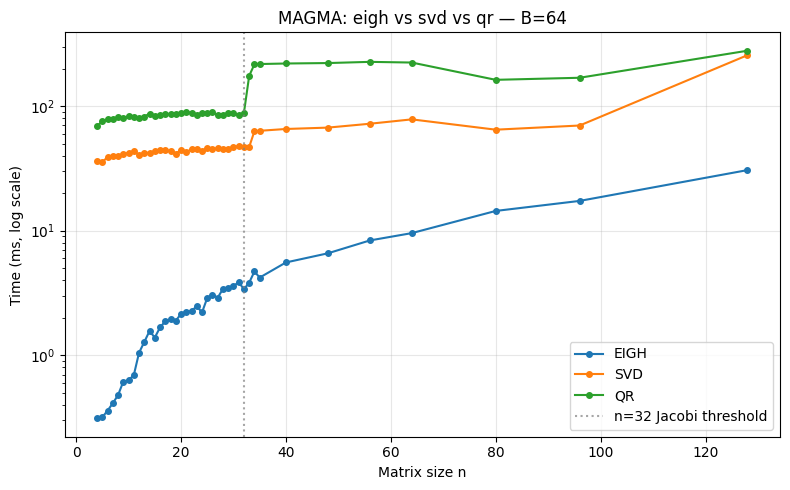

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for op in ops:
    key = f'{op}_ms'
    ax.semilogy(n_arr, res_magma[key], 'o-', ms=4, label=op.upper())

ax.axvline(x=32, color='gray', ls=':', alpha=0.7, label='n=32 Jacobi threshold')
ax.set_xlabel('Matrix size n')
ax.set_ylabel('Time (ms, log scale)')
ax.set_title(f'MAGMA: eigh vs svd vs qr — B={B}')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()